# Task 2: Technical Indicators and Visualization

This notebook loads stock prices, computes SMA/EMA/RSI/MACD, and visualizes market behavior.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.data_loader import load_stock_prices
from src.indicators import ema, macd, rsi, sma

sns.set_theme(style='whitegrid')
DATA_PATH = Path('../data/raw/stock_prices.csv')
print(f'Stock data path: {DATA_PATH}')
print(f'File exists: {DATA_PATH.exists()}')

Stock data path: ..\data\raw\stock_prices.csv
File exists: True


In [2]:
df = load_stock_prices(str(DATA_PATH))
print(df.head())
print('\nColumns:', list(df.columns))
print('\nRows:', len(df))
print('Unique stocks:', df['stock'].nunique())

✓ Loaded 18019 trading days
✓ Date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00
✓ Price range: $0.17 to $379.84
        date      open      high       low     close     volume stock
0 2009-01-02  2.575630  2.730385  2.554037  2.721686  746015200  AAPL
1 2009-01-02  2.567500  2.726500  2.553500  2.718000  145928000  AMZN
2 2009-01-02  0.184982  0.201027  0.184294  0.199652  497124000  NVDA
3 2009-01-02  7.633949  7.960977  7.557264  7.948608  144961322  GOOG
4 2009-01-05  7.940692  8.194003  7.792268  8.115089  196293007  GOOG

Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'stock']

Rows: 18019
Unique stocks: 5


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
print('Missing values by column:')
print(missing)

print('\nDate range:', df['date'].min(), 'to', df['date'].max())
print('Stocks available:', sorted(df['stock'].unique().tolist()))

Missing values by column:
date      0
open      0
high      0
low       0
close     0
volume    0
stock     0
dtype: int64

Date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00
Stocks available: ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']


In [4]:
symbol = 'AAPL' if 'AAPL' in df['stock'].unique() else df['stock'].iloc[0]
d = df[df['stock'] == symbol].copy().sort_values('date').reset_index(drop=True)

d['sma_20'] = sma(d['close'], 20)
d['sma_50'] = sma(d['close'], 50)
d['ema_20'] = ema(d['close'], 20)
d['rsi_14'] = rsi(d['close'], 14)
macd_df = macd(d['close'])
d = pd.concat([d, macd_df], axis=1)

print(f'Using symbol: {symbol}')
print(d[['date','close','sma_20','sma_50','ema_20','rsi_14','macd','signal','hist']].tail())

Using symbol: AAPL
           date       close      sma_20      sma_50      ema_20     rsi_14  \
3769 2023-12-22  191.788757  191.856618  183.572859  191.510231  54.672784   
3770 2023-12-26  191.243912  192.018094  183.858864  191.484867  53.090049   
3771 2023-12-27  191.342972  192.154308  184.149424  191.471353  53.354446   
3772 2023-12-28  191.768951  192.362839  184.479567  191.499696  54.540999   
3773 2023-12-29  190.728775  192.490633  184.814828  191.426275  51.121347   

          macd    signal      hist  
3769  2.633141  3.235256 -0.602115  
3770  2.304751  3.049155 -0.744404  
3771  2.029104  2.845145 -0.816041  
3772  1.823998  2.640915 -0.816918  
3773  1.559539  2.424640 -0.865101  


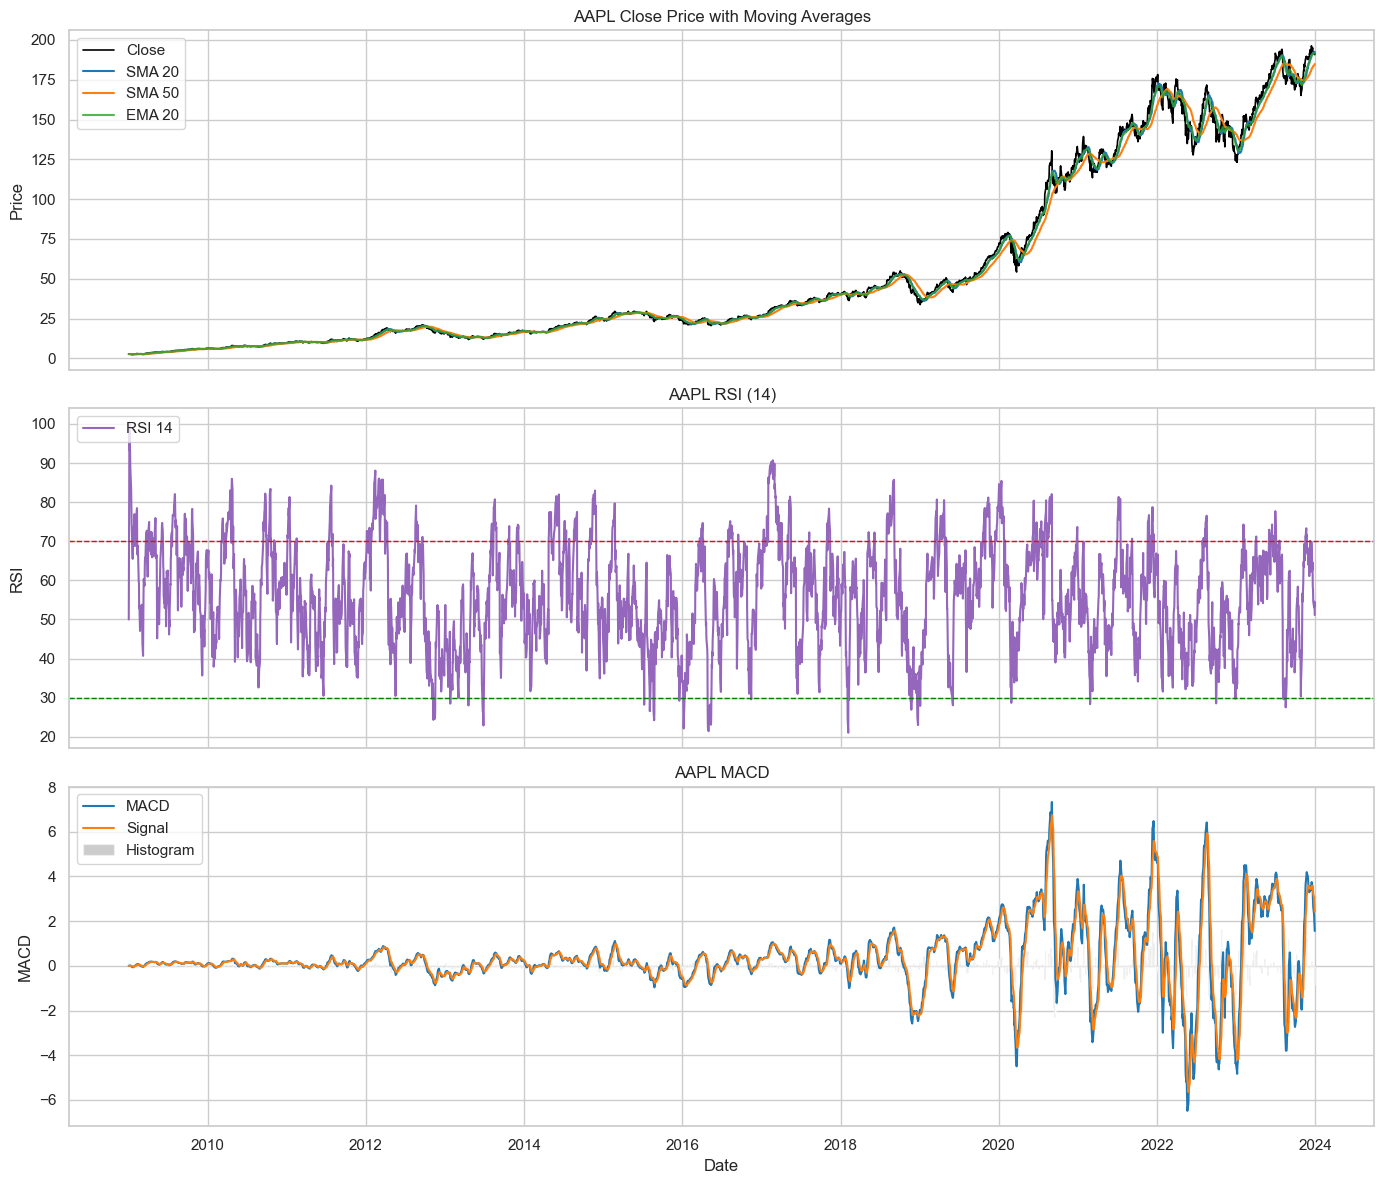

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(d['date'], d['close'], label='Close', color='black', linewidth=1.2)
axes[0].plot(d['date'], d['sma_20'], label='SMA 20', color='tab:blue')
axes[0].plot(d['date'], d['sma_50'], label='SMA 50', color='tab:orange')
axes[0].plot(d['date'], d['ema_20'], label='EMA 20', color='tab:green', alpha=0.8)
axes[0].set_title(f'{symbol} Close Price with Moving Averages')
axes[0].set_ylabel('Price')
axes[0].legend(loc='upper left')

axes[1].plot(d['date'], d['rsi_14'], label='RSI 14', color='tab:purple')
axes[1].axhline(70, color='red', linestyle='--', linewidth=1)
axes[1].axhline(30, color='green', linestyle='--', linewidth=1)
axes[1].set_title(f'{symbol} RSI (14)')
axes[1].set_ylabel('RSI')
axes[1].legend(loc='upper left')

axes[2].plot(d['date'], d['macd'], label='MACD', color='tab:blue')
axes[2].plot(d['date'], d['signal'], label='Signal', color='tab:orange')
axes[2].bar(d['date'], d['hist'], label='Histogram', color='gray', alpha=0.4)
axes[2].set_title(f'{symbol} MACD')
axes[2].set_ylabel('MACD')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

## Notes
- Missing values were checked before indicator computation.
- Indicators are computed using reusable utilities in `src/indicators.py`.
- If needed, extend this notebook to loop over all symbols and save per-symbol plots.